<a href="https://colab.research.google.com/github/Dhanushiya-tech/Portfolio-sample/blob/main/Classify_Waste_Products.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import sys
print(sys.version)

# Define the path to your test data directory
test_dir = '/content/datasets/flower_photos' # <<< --- IMPORTANT: Update this path

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


### Download a dataset using `wget`

You can use the `wget` command in a code cell to download files directly from a URL. Replace the example URL with the actual link to your dataset.

In [21]:
import os

# Example URL for a dataset (replace with your actual URL)
dataset_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'

# Define the directory where you want to save the dataset
download_dir = '/content/datasets'
os.makedirs(download_dir, exist_ok=True)

# Get the filename from the URL
filename = os.path.basename(dataset_url)
output_path = os.path.join(download_dir, filename)

# Use wget to download the file
!wget -O {output_path} {dataset_url}

print(f"Downloaded {filename} to {download_dir}")

# If it's a compressed file, you might want to extract it
if filename.endswith('.tgz') or filename.endswith('.tar.gz'):
    print(f"Extracting {filename}...")
    !tar -xzf {output_path} -C {download_dir}
    print("Extraction complete.")

# List contents of the download directory to verify
print(f"\nContents of {download_dir}:")
!ls {download_dir}

--2026-04-23 00:39:54--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.212.207, 192.178.219.207, 173.194.215.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.212.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘/content/datasets/flower_photos.tgz’

/content/datasets/f 100%[===================>] 218.21M   142MB/s    in 1.5s    

2026-04-23 00:39:56 (142 MB/s) - ‘/content/datasets/flower_photos.tgz’ saved [228813984/228813984]

Downloaded flower_photos.tgz to /content/datasets
Extracting flower_photos.tgz...
Extraction complete.

Contents of /content/datasets:
flower_photos  flower_photos.tgz


In [11]:
import os

if os.path.exists(test_dir):
    print(f"The path '{test_dir}' exists.")
else:
    print(f"Error: The path '{test_dir}' does NOT exist. Please update the 'test_dir' variable with a valid path to your test data.")

Error: The path 'path/to/your/test/data' does NOT exist. Please update the 'test_dir' variable with a valid path to your test data.


In [14]:
import os

if os.path.exists(test_dir) and os.path.isdir(test_dir):
    print(f"Contents of '{test_dir}':")
    for item in os.listdir(test_dir):
        print(item)
else:
    print(f"Error: The path '{test_dir}' is not a valid directory or does not exist.")

Error: The path 'path/to/your/test/data' is not a valid directory or does not exist.


In [15]:
import os

current_directory = os.getcwd()
print(f"Current working directory: {current_directory}")

Current working directory: /content


In [16]:
import os

sample_data_path = '/content/sample_data'

if os.path.exists(sample_data_path) and os.path.isdir(sample_data_path):
    print(f"Contents of '{sample_data_path}':")
    for item in os.listdir(sample_data_path):
        print(item)
else:
    print(f"Error: The path '{sample_data_path}' is not a valid directory or does not exist.")

Contents of '/content/sample_data':
anscombe.json
README.md
mnist_train_small.csv
california_housing_test.csv
california_housing_train.csv
mnist_test.csv


In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
print(tf.__version__)

2.19.0


In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Using the previously defined validation_test_datagen
test_generator = validation_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3670 images belonging to 5 classes.


The `ImageDataGenerator` class in Keras (part of TensorFlow) is used for image augmentation and preparing image data for neural networks. Key parameters include:

*   `rescale`: Rescales the pixel values (e.g., `1./255` to normalize to the [0, 1] range).
*   `rotation_range`: Degree range for random rotations.
*   `width_shift_range` and `height_shift_range`: Range for random horizontal/vertical shifts.
*   `shear_range`: Shear intensity (shear angle in degrees).
*   `zoom_range`: Range for random zoom.
*   `horizontal_flip` and `vertical_flip`: Randomly flip inputs horizontally/vertically.
*   `fill_mode`: Strategy for filling newly created pixels, which can appear after a rotation or a width/height shift.

After defining the `ImageDataGenerator`, you use its `flow_from_directory()` method to load images from disk.

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Example of an ImageDataGenerator for training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to [0, 1]
    rotation_range=20,       # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,   # Randomly shift images horizontally by up to 20% of width
    height_shift_range=0.2,  # Randomly shift images vertically by up to 20% of height
    shear_range=0.2,         # Apply shear transformation
    zoom_range=0.2,          # Randomly zoom images
    horizontal_flip=True,    # Randomly flip images horizontally
    fill_mode='nearest'      # Strategy for filling in new pixels
)

# Example of an ImageDataGenerator for validation/testing (usually only rescaling)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerators defined: train_datagen and validation_test_datagen")

ImageDataGenerators defined: train_datagen and validation_test_datagen


In [25]:
# Initialize train_generator using train_datagen
train_generator = train_datagen.flow_from_directory(
    test_dir,  # Use the same directory for now, as it contains both train/validation splits in many cases
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

print(f"Found {train_generator.samples} training images belonging to {train_generator.num_classes} classes.")

Found 3670 images belonging to 5 classes.
Found 3670 training images belonging to 5 classes.


In [26]:
print(len(train_generator))

115


In [27]:
model.summary()

NameError: name 'model' is not defined

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the number of classes (from your ImageDataGenerator output)
num_classes = train_generator.num_classes

# Create a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer with num_classes and softmax activation
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


I've defined a simple CNN model for image classification. Here's a brief overview of the architecture:

*   **Convolutional Layers (`Conv2D`):** These layers extract features from the images. We start with 32 filters, then 64, and finally 128, increasing complexity.
*   **Max Pooling Layers (`MaxPooling2D`):** These layers reduce the spatial dimensions of the feature maps, helping to make the model more robust to variations and reduce computation.
*   **Flatten Layer:** This converts the 2D feature maps into a 1D vector so it can be fed into dense layers.
*   **Dense Layers:** These are fully connected layers. The first `Dense` layer has 512 units and a 'relu' activation function. A `Dropout` layer is added for regularization to prevent overfitting.
*   **Output Layer (`Dense`):** This layer has `num_classes` units (which is 5 for your flower dataset) and uses a 'softmax' activation function, which is suitable for multi-class classification, outputting probabilities for each class.

The model is compiled with the `adam` optimizer, `categorical_crossentropy` loss (appropriate for multi-class classification), and `accuracy` as a metric.

In [29]:
# Now, let's display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,398,661 (169.37 MB)

 Trainable params: 44,398,661 (169.37 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
epochs = 10 # You can adjust the number of epochs
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=test_generator
)

print("Model training complete.")

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 627s 5s/step - accuracy: 0.4627 - loss: 1.2587 - val_accuracy: 0.5357 - val_loss: 1.1409
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 622s 5s/step - accuracy: 0.5559 - loss: 1.0947 - val_accuracy: 0.6507 - val_loss: 0.9129
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 618s 5s/step - accuracy: 0.6202 - loss: 0.9692 - val_accuracy: 0.6583 - val_loss: 0.8833
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 619s 5s/step - accuracy: 0.6556 - loss: 0.8865 - val_accuracy: 0.6782 - val_loss: 0.8197
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 622s 5s/step - accuracy: 0.6687 - loss: 0.8512 - val_accuracy: 0.7319 - val_loss: 0.6915
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 617s 5s/step - accuracy: 0.6790 - loss: 0.8034 - val_accuracy: 0.7196 - val_loss: 0.7202
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 624s 5s/step - accuracy: 0.7011 - loss: 0.7717 - val_accuracy: 0.7387 - val_loss: 0.6905
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 639s 6s/step - accuracy: 0.7125 - loss: 0.7570 - val_accu

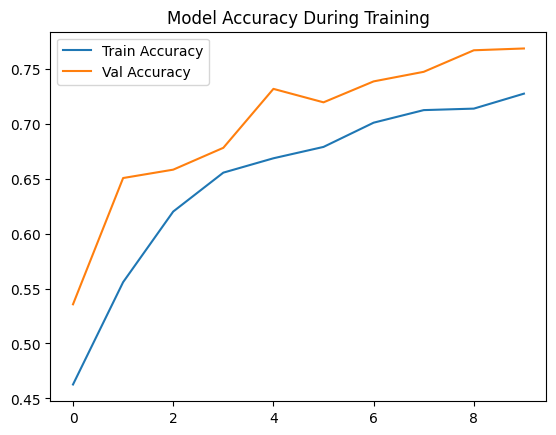

In [37]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy During Training')
plt.show()

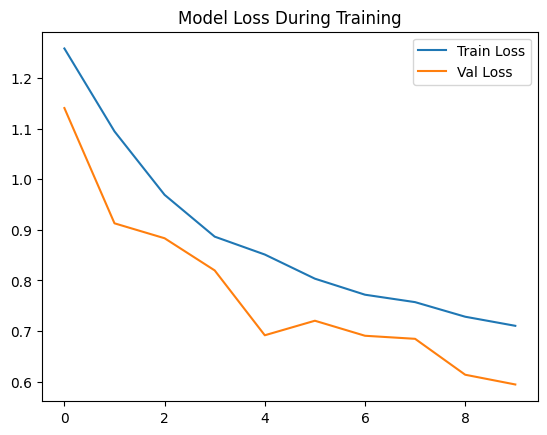

In [39]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss During Training')
plt.show()

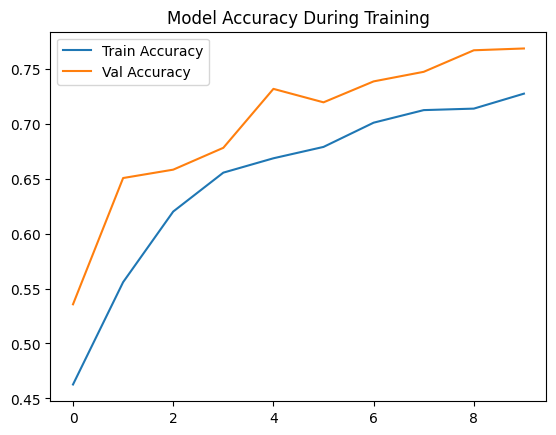

In [41]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy During Training')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


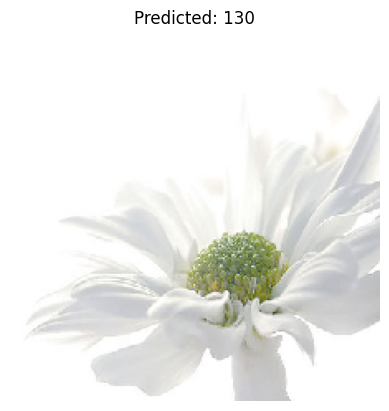

In [42]:
import numpy as np

index_to_plot = 1

img, label = test_generator[index_to_plot]
prediction = model.predict(img)

plt.imshow(img[0])
plt.title(f"Predicted: {np.argmax(prediction)}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 994ms/step


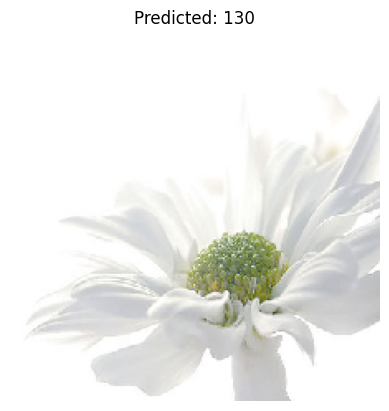

In [44]:
prediction_fine = model.predict(img)

plt.imshow(img[0])
plt.title(f"Predicted: {np.argmax(prediction_fine)}")
plt.axis('off')
plt.show()